# PACSUN2603 Spectrograms and Scalograms
NOTE: These datasets aren't synchronized, which is probably why it looks like things happened in the scalogram for 117 before 123. For best results, pull from the ISAC3.csv dataset instead of the individual files.

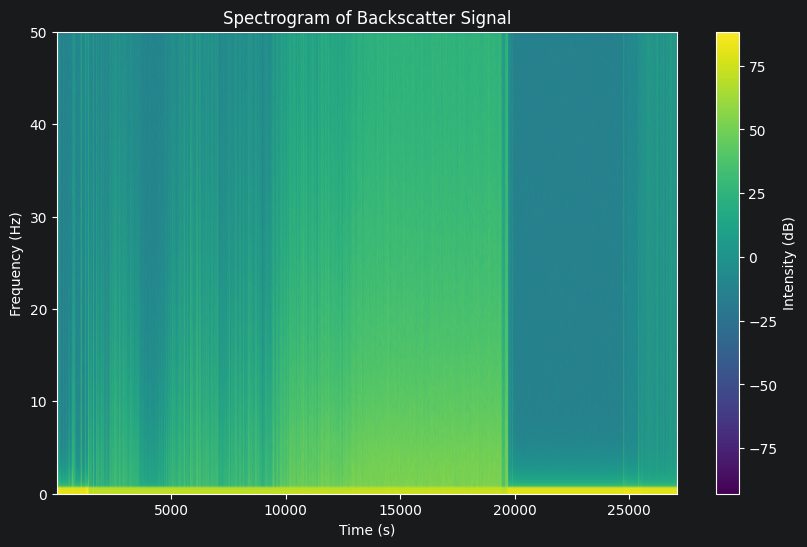

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

df = pd.read_csv('ISAC3_top_123.TXT', skiprows = 4)
df.columns = ['unixTime','background','ambient', 'backscatter', 'pressure','waterTemp','battery']

# 2. Define the signal and sampling frequency
# 'fs' is the number of samples taken per second.
# You need to determine this based on your sensor's specifications.
fs = 100  # Example: 100 Hz
sig = df['backscatter'].values

# 3. Create the Spectrogram
plt.figure(figsize=(10, 6))
# NFFT is the number of data points used in each block for the FFT
# noverlap is the number of points of overlap between blocks
Pxx, frequencies, bins, im = plt.specgram(sig, NFFT=256, Fs=fs, noverlap=128, cmap='viridis')

plt.title('Spectrogram of Backscatter Signal')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Intensity (dB)')
plt.show()

## Wavelet transform / Scalogram

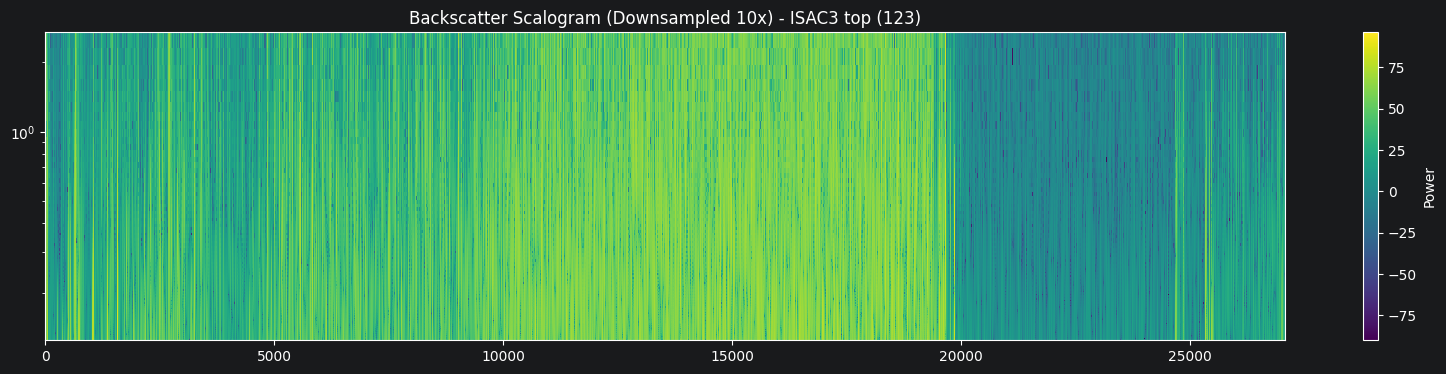

<Figure size 640x480 with 0 Axes>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy import signal


df = pd.read_csv('ISAC3_top_123.TXT', skiprows = 4)
df.columns = ['unixTime','background','ambient', 'backscatter', 'pressure','waterTemp','battery']

# filter to overlap between the 2 datasets (manually)
df = df[df['unixTime'] <= 1774232176]
df = df[df['unixTime'] >= 1774110676]

# 2. Define the signal and sampling frequency
# 'fs' is the number of samples taken per second.
# You need to determine this based on your sensor's specifications.
fs = 100  # Example: 100 Hz
sig = df['backscatter'].values

# 1. Downsample the signal
# If fs was 100Hz, decimate(10) makes it 10Hz.
downsample_factor = 10
sig_resampled = signal.decimate(df['backscatter'].values, downsample_factor)
fs_new = fs / downsample_factor

sig_resampled = sig_resampled - np.mean(sig_resampled)

# 2. Reduce the number of scales
# 100 scales is fine for a resampled signal, but let's be conservative
# widths = np.geomspace(1, 50, num=50)
widths = np.linspace(1, 20, num=100)

# 3. Perform CWT
# Use a real wavelet like 'mexh' to save 2x memory if you don't need phase info,
# or stick with cmor but be mindful of the size.
# wavelet = 'cmor1.5-1.0'
wavelet = "mexh"
cwtmatr, freqs = pywt.cwt(sig_resampled, widths, wavelet, sampling_period=1/fs_new)

# 4. Plotting (using 'shading="flat"' to be faster on large arrays)
# Calculate limits based on the 1st and 99th percentile
# Use np.log10 to see decibels/orders of magnitude
power = np.abs(cwtmatr)**2
log_power = 10 * np.log10(power + 1e-9) # Add a tiny constant to avoid log(0)
v_min, v_max = np.percentile(log_power, [20, 90])

plt.figure(figsize=(20, 4))

# plt.pcolormesh(np.arange(len(sig_resampled)) / fs_new,
#                freqs,
#                np.abs(cwtmatr)**2,
#                shading='nearest',
#                cmap='viridis',
#                vmin=v_min,
#                vmax=v_max)

plt.pcolormesh(np.arange(len(sig_resampled)) / fs_new,
               freqs,
               log_power,
               shading='nearest',
               cmap='viridis')

plt.yscale('log')

plt.colorbar(label='Power')
plt.title(f'Backscatter Scalogram (Downsampled {downsample_factor}x) - ISAC3 top (123)')
plt.show()
plt.savefig('ISAC3_123_scalogram.png')

3520899
2634268


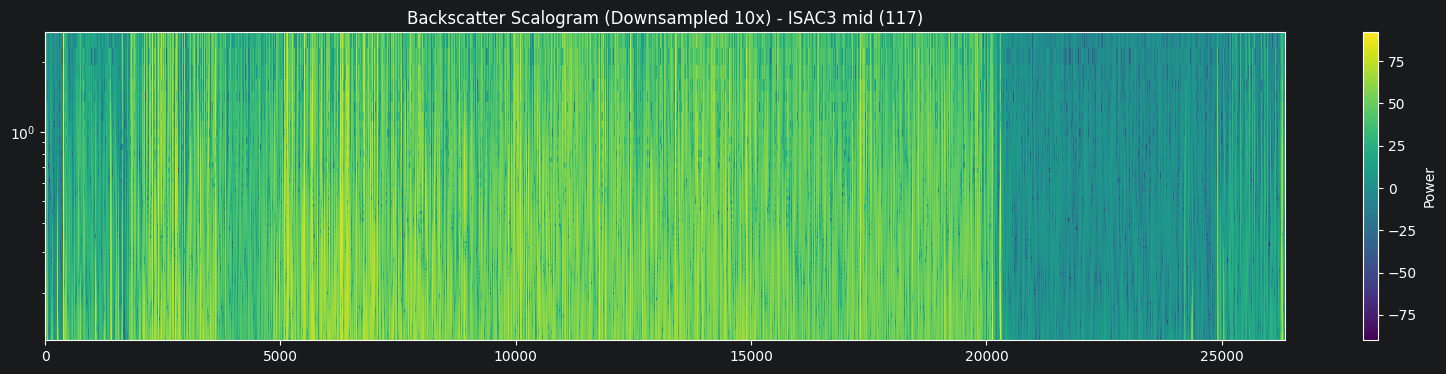

<Figure size 640x480 with 0 Axes>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy import signal


df = pd.read_csv('ISAC3_mid_117.TXT', skiprows = 4)
df.columns = ['unixTime','background','ambient', 'backscatter', 'pressure','waterTemp','battery']

print(len(df))
df = df[df['unixTime'] <= 1774232176]
df = df[df['unixTime'] >= 1774110676]
print(len(df))

# 2. Define the signal and sampling frequency
# 'fs' is the number of samples taken per second.
# You need to determine this based on your sensor's specifications.
fs = 100  # Example: 100 Hz
sig = df['backscatter'].values

# 1. Downsample the signal
# If fs was 100Hz, decimate(10) makes it 10Hz.
downsample_factor = 10
sig_resampled = signal.decimate(df['backscatter'].values, downsample_factor)
fs_new = fs / downsample_factor

sig_resampled = sig_resampled - np.mean(sig_resampled)

# 2. Reduce the number of scales
# 100 scales is fine for a resampled signal, but let's be conservative
# widths = np.geomspace(1, 50, num=50)
widths = np.linspace(1, 20, num=100)

# 3. Perform CWT
# Use a real wavelet like 'mexh' to save 2x memory if you don't need phase info,
# or stick with cmor but be mindful of the size.
# wavelet = 'cmor1.5-1.0'
wavelet = "mexh"
cwtmatr, freqs = pywt.cwt(sig_resampled, widths, wavelet, sampling_period=1/fs_new)

# 4. Plotting (using 'shading="flat"' to be faster on large arrays)
# Calculate limits based on the 1st and 99th percentile
# Use np.log10 to see decibels/orders of magnitude
power = np.abs(cwtmatr)**2
log_power = 10 * np.log10(power + 1e-9) # Add a tiny constant to avoid log(0)
v_min, v_max = np.percentile(log_power, [20, 90])

plt.figure(figsize=(20, 4))

# plt.pcolormesh(np.arange(len(sig_resampled)) / fs_new,
#                freqs,
#                np.abs(cwtmatr)**2,
#                shading='nearest',
#                cmap='viridis',
#                vmin=v_min,
#                vmax=v_max)

plt.pcolormesh(np.arange(len(sig_resampled)) / fs_new,
               freqs,
               log_power,
               shading='nearest',
               cmap='viridis')

plt.yscale('log')

plt.colorbar(label='Power')
plt.title(f'Backscatter Scalogram (Downsampled {downsample_factor}x) - ISAC3 mid (117)')
plt.show()
plt.savefig('ISAC3_117_scalogram.png')